# Pyomo.DAE: Racing Example Revisited
**Prepared by:** Prof. Alexander Dowling, Molly Dougher (mdoughe6@nd.edu, 2023)

```{warning}
**AI-drafted prose, not yet reviewed by Prof. Dowling.**

Some of the writing on this page was drafted or edited by an AI assistant and has not yet been reviewed: 3 rewritten and 1 added markdown cells, measured against the last version of this notebook predating AI editing (2026-08-17).

This notice is about the *prose only*. It says nothing either way about the code, the numbers or the figures, which are checked separately. It is removed once the page has been reviewed.
```

In [1]:
# Install Pyomo and solvers for Google Colab
import sys

if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/optimization/main/notebooks/helper.py"
    import helper

    helper.easy_install()
else:
    sys.path.insert(0, "../")
    import helper
helper.set_plotting_style()

# import Pyomo library
import pyomo.environ as pyo
import pyomo.dae as dae
import matplotlib.pyplot as plt
from pyomo.environ import units
from pyomo.util.check_units import assert_units_consistent

## Car Example

Adapted from https://github.com/Pyomo/pyomo/blob/master/examples/dae/car_example.py

You are a race car driver with a simple goal. Drive distance $L$ in the minimal amount of time **but** come to a complete stop at the finish line.

### Optimal Control Problem Formulation

Mathematically, you want to solve the following optimal control problem:

$$\begin{align*}
\min_{u} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{dt} = v \\
& \frac{dv}{dt} = u - R v^2 \\
& x(t=0) = 0, ~~ x(t=t_f) = L \\
& v(t=0) = 0, ~~ v(t=t_f) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

where $u$ is the acceleration/braking (your control variable) and $R$ is the drag coefficient (parameter).

### Scale Time

Let $t = \tau \cdot t_f$ where $\tau \in [0,1]$. Thus $dt = t_f d\tau$. The optimal control problem becomes:

$$\begin{align*}
\min_{u} \quad & t_f \\
\mathrm{s.t.} \quad & \frac{dx}{d\tau} = t_f v \\
& \frac{dv}{d\tau} = t_f (u - R v^2) \\
& x(\tau = 0) = 0, ~~ x(\tau = 1) = L \\
& v(\tau = 0) = 0, ~~ v(\tau = 1) = 0 \\
& -3 \leq u \leq 1
\end{align*}$$

### Orthogonal Collocation on Finite Elements: Manual Approach

Here is the "classical"/"old school" way of manually implementing collocation on finite elements with sets.

**Indices and Sets**
* Finite elements: $i \in \mathcal{I} = \{1,2,...,N_{FE}\}$
* Finite elements (except first): $\mathcal{I} \setminus 1$
* Internal collocation points: $j,k \in \mathcal{J} = \{1,2,...,N_{C}\}$


**Parameters**
* Coefficients in collocation/Runge-Kutta formula: $a_{k,j}$
* Drag coefficient: $R$
* Race length: $L$
* Scaled time for each finite element: $h_i = \frac{1}{N_{FE}}$

**Variables**
* Position (internal collocation points): $x_{i,j}$
* Position (beginning of each finite element): $\bar{x}_{i}$
* Position derivative (internal collocation points): $\dot{x}_{i,j}$
* Velocity (internal collocation points): $v_{i,j}$
* Velocity (beginning of each finite element): $\bar{v}_{i}$
* Velocity derivative (internal collocation points): $\dot{v}_{i,j}$
* Time (internal collocation points): $t_{i,j}$
* Time (beginning of each finite element): $\bar{t}_{i}$
* Acceleration (control degrees of freedom): $u_i$

**Objective and Constraints**

$$\begin{align*}
\min \quad & t_f \\
\mathrm{s.t.} \quad & \mathrm{Differential~equation~for~x:} \\ 
& x_{i,j} = \bar{x}_{i} + h_i \sum_{k \in \mathcal{J}} a_{k,j} \dot{x}_{i,k},\quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\
& \bar{x}_{i} = \bar{x}_{i-1} + h_{i-1} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{x}_{i-1,k},\quad \forall i \in \mathcal{I} \setminus 1\\
& \dot{x}_{i,j} = t_f v_{i,j}, \quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\ \\
& \mathrm{Differential~equation~for~v:} \\ 
& v_{i,j} = \bar{v}_{i} + h_i \sum_{k \in \mathcal{J}} a_{k,j} \dot{v}_{i,k},\quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\
& \bar{v}_{i} = \bar{v}_{i-1} + h_{i-1} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{v}_{i-1,k},\quad \forall i \in \mathcal{I} \setminus 1\\
& \dot{v}_{i,j} = t_f (u_{i} - R v_{i,j}^2), \quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\ \\
& \mathrm{Differential~equation~for~time:} \\
& t_{i,j} = \bar{t}_{i} + h_i \sum_{k \in \mathcal{J}} a_{k,j} t_f,\quad \forall i \in \mathcal{I},~j \in \mathcal{J} \\
& \bar{t}_{i} = \bar{t}_{i-1} + h_{i-1} \sum_{k \in \mathcal{J}} a_{k,N_C} t_f,\quad \forall i \in \mathcal{I} \setminus 1\\ \\
& \mathrm{Initial~conditions:} \\ 
& \bar{x}_{1} = 0, \quad \bar{v}_{1} = 0, \quad \bar{t}_1 = 0\\ \\
& \mathrm{Boundary~conditions:} \\ 
& L = \bar{x}_{N_{FE}} + h_{N_{FE}} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{x}_{N_{FE},k}, \\
& 0 = \bar{v}_{N_{FE}} + h_{N_{FE}} \sum_{k \in \mathcal{J}} a_{k,N_C} \dot{v}_{N_{FE},k}, \\ \\
& \mathrm{Bounds~on~acceleration:} \\
& -3 \leq u_i \leq 1, \quad \forall i \in \mathcal{I}
\end{align*}$$

In [2]:
# Define the model
m2 = pyo.ConcreteModel()

# Define model parameters.
#
# R multiplies v**2 to give an acceleration, so R has units of 1/length.
m2.R = pyo.Param(initialize=0.001, units=1 / units.m)  # Friction factor
m2.L = pyo.Param(initialize=100.0, units=units.m)  # Final position

# Define finite elements and collocation points
NFE = 15  # Number of finite elements
NC = 3  # Number of collocation points
m2.I = pyo.Set(initialize=pyo.RangeSet(1, NFE))  # Set of finite elements
m2.J = pyo.Set(initialize=pyo.RangeSet(1, NC))  # Set of internal collocation points

# Define first order derivative collocation matrix
A = {}
A[1, 1] = 0.19681547722366
A[1, 2] = 0.39442431473909
A[1, 3] = 0.37640306270047
A[2, 1] = -0.06553542585020
A[2, 2] = 0.29207341166523
A[2, 3] = 0.51248582618842
A[3, 1] = 0.02377097434822
A[3, 2] = -0.04154875212600
A[3, 3] = 0.11111111111111

# Define A matrix as a model parameter (collocation coefficients are dimensionless)
m2.a = pyo.Param(m2.J, m2.J, initialize=A)

# Define step for each finite element. This is a fraction of the SCALED time
# tau in [0, 1], so it is dimensionless -- the physical step is h * tf seconds.
m2.h = pyo.Param(m2.I, initialize=1 / NFE)

# Define objective (final time)
m2.tf = pyo.Var(domain=pyo.NonNegativeReals, units=units.s)

# Variables for x (position). Because we differentiate with respect to the
# DIMENSIONLESS tau, xdot carries the same units as x itself.
m2.x0 = pyo.Var(m2.I, units=units.m)  # Beginning of each finite element
m2.x = pyo.Var(m2.I, m2.J, units=units.m)  # Internal collocation points
m2.xdot = pyo.Var(m2.I, m2.J, units=units.m)  # Derivative, internal collocation points

# Variables for v (velocity)
m2.v0 = pyo.Var(m2.I, units=units.m / units.s)  # Beginning of each finite element
m2.v = pyo.Var(m2.I, m2.J, units=units.m / units.s)  # Internal collocation points
m2.vdot = pyo.Var(
    m2.I, m2.J, units=units.m / units.s
)  # Derivative, internal collocation points

# Variables for t
m2.t0 = pyo.Var(m2.I, units=units.s)  # Beginning of each finite element
m2.t = pyo.Var(m2.I, m2.J, units=units.s)  # Internal collocation points

# Acceleration
m2.u = pyo.Var(
    m2.I, bounds=(-3, 1), units=units.m / units.s**2
)  # Control DOF (bounds in m/s**2)


### Finite Element Collocation Equations
# position
@m2.Constraint(m2.I, m2.J)
def FECOLx(m2, i, j):
    return m2.x[i, j] == m2.x0[i] + m2.h[i] * sum(
        m2.a[k, j] * m2.xdot[i, k] for k in m2.J
    )


# velocity
@m2.Constraint(m2.I, m2.J)
def FECOLv(m2, i, j):
    return m2.v[i, j] == m2.v0[i] + m2.h[i] * sum(
        m2.a[k, j] * m2.vdot[i, k] for k in m2.J
    )


# time
@m2.Constraint(m2.I, m2.J)
def FECOLt(m2, i, j):
    return m2.t[i, j] == m2.t0[i] + m2.h[i] * sum(m2.a[k, j] * m2.tf for k in m2.J)


### Continuity Equations
# position
@m2.Constraint(m2.I)
def CONx(m2, i):
    if i == 1:
        return pyo.Constraint.Skip
    else:
        return m2.x0[i] == m2.x0[i - 1] + m2.h[i - 1] * sum(
            m2.a[k, NC] * m2.xdot[i - 1, k] for k in m2.J
        )


# velocity
@m2.Constraint(m2.I)
def CONv(m2, i):
    if i == 1:
        return pyo.Constraint.Skip
    else:
        return m2.v0[i] == m2.v0[i - 1] + m2.h[i - 1] * sum(
            m2.a[k, NC] * m2.vdot[i - 1, k] for k in m2.J
        )


# time
@m2.Constraint(m2.I)
def CONt(m2, i):
    if i == 1:
        return pyo.Constraint.Skip
    else:
        return m2.t0[i] == m2.t0[i - 1] + m2.h[i - 1] * sum(
            m2.a[k, NC] * m2.tf for k in m2.J
        )


### Differential equations
# position
@m2.Constraint(m2.I, m2.J)
def ODEx(m2, i, j):
    return m2.xdot[i, j] == m2.tf * m2.v[i, j]


# velocity
@m2.Constraint(m2.I, m2.J)
def ODEv(m2, i, j):
    return m2.vdot[i, j] == m2.tf * (m2.u[i] - m2.R * m2.v[i, j] ** 2)


### Initial conditions
m2.xIC = pyo.Constraint(expr=m2.x0[1] == 0)
m2.vIC = pyo.Constraint(expr=m2.v0[1] == 0)
m2.tIC = pyo.Constraint(expr=m2.t0[1] == 0)

### Boundary conditions
m2.xBC = pyo.Constraint(
    expr=m2.L
    == m2.x0[NFE] + m2.h[NFE] * sum(m2.a[k, NC] * m2.xdot[NFE, k] for k in m2.J)
)
m2.vBC = pyo.Constraint(
    expr=0 == m2.v0[NFE] + m2.h[NFE] * sum(m2.a[k, NC] * m2.vdot[NFE, k] for k in m2.J)
)

### Set objective
m2.obj = pyo.Objective(expr=m2.tf)

### Check dimensional consistency.
#
# Here we wrote the collocation equations OURSELVES, so there is nothing for
# Pyomo to add later and nothing to trip over: the check works on the finished
# model. Compare with the Pyomo.dae version below, where the discretization
# equations are generated for us. See ./units_and_pyomo_dae.md
assert_units_consistent(m2)
print("Manual collocation model: units are consistent.")

Manual collocation model: units are consistent.


In [3]:
# Solve the model
solver = pyo.SolverFactory("ipopt")
results = solver.solve(m2, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("final time = %6.2f" % (pyo.value(m2.tf)))

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     1093
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      105

Total number of variables............................:      286
                     variables with only lower bounds:        1
                variables with lower and upper bounds:       15
                     variables with only upper bounds:        0
Total number of equality constraints.................:      272
Total number

   1r 9.9999900e-03 1.00e+02 9.99e+02   2.0 0.00e+00    -  0.00e+00 4.40e-08R  3
   2r 3.0578540e+00 9.99e+01 9.31e+02   2.0 4.49e+01    -  1.35e-01 6.80e-02f  2
   3r 2.2147899e+00 9.91e+01 5.68e+02   1.3 2.16e+00    -  1.00e+00 3.91e-01f  1
   4r 2.0632709e+00 9.88e+01 4.20e+02   0.6 1.92e+00    -  7.91e-01 2.59e-01f  1
   5r 2.8236279e+00 9.78e+01 2.47e+02   0.6 6.49e+00    -  5.25e-01 4.12e-01f  1
   6r 6.1897113e+00 9.47e+01 1.86e+02  -0.1 8.25e+00    -  3.79e-01 6.85e-01f  1
   7r 9.1974909e+00 8.83e+01 1.23e+02  -0.1 1.21e+01    -  2.99e-01 7.01e-01f  1
   8r 9.6970537e+00 8.58e+01 2.56e+00  -0.1 3.39e+00    -  1.00e+00 1.00e+00f  1
   9  9.9061474e+00 8.51e+01 9.92e-01  -1.0 1.15e+02    -  3.63e-01 7.81e-03h  8
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10  1.0294740e+01 8.38e+01 1.07e+00  -1.0 1.17e+02    -  7.18e-01 1.56e-02h  7
  11  1.0567140e+01 8.26e+01 1.34e+00  -1.0 1.26e+02    -  6.33e-01 1.37e-02h  7
  12  1.0857928e+01 8.14e+01

iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  20  1.8114159e+01 3.86e+00 2.54e-01  -1.0 1.61e+01    -  1.00e+00 1.00e+00w  1
  21  1.7666544e+01 9.73e-02 1.13e-03  -1.0 2.28e+00    -  1.00e+00 1.00e+00h  1
  22  1.6720659e+01 9.70e-01 2.11e-02  -2.5 8.57e+00    -  8.71e-01 1.00e+00h  1
  23  1.6583213e+01 4.50e-02 1.04e-03  -2.5 3.48e+00  -4.0 1.00e+00 1.00e+00h  1
  24  1.6557944e+01 1.48e-02 8.92e-03  -2.5 4.01e+00    -  1.00e+00 7.71e-01h  1


  25  1.6522447e+01 1.45e-03 1.92e-05  -3.8 2.96e-01    -  1.00e+00 1.00e+00h  1
  26  1.6520217e+01 7.90e-06 4.91e-08  -5.7 3.16e-02    -  1.00e+00 1.00e+00h  1
  27  1.6520191e+01 1.15e-09 6.26e-12  -8.6 4.04e-04    -  1.00e+00 1.00e+00h  1

Number of Iterations....: 27

                                   (scaled)                 (unscaled)
Objective...............:   1.6520190872026873e+01    1.6520190872026873e+01
Dual infeasibility......:   6.2564612671131945e-12    6.2564612671131945e-12
Constraint violation....:   1.1536656074895291e-09    1.1536656074895291e-09
Variable bound violation:   2.1896629398554524e-08    2.1896629398554524e-08
Complementarity.........:   2.5317854706692709e-09    2.5317854706692709e-09
Overall NLP error.......:   2.5317854706692709e-09    2.5317854706692709e-09


Number of objective function evaluations             = 108
Number of objective gradient evaluations             = 22
Number of equality constraint evaluations            = 108
Number of inequ

final time =  16.52


### Orthogonal Collocation on Finite Elements: Pyomo.dae

There is a better way! We can use `Pyomo.dae` to automatically formulate the collocation equations.

#### Declare Model

In [4]:
# Define the  model
m = pyo.ConcreteModel()

# Define the model parameters
m.R = pyo.Param(initialize=0.001, units=1 / units.m)  # Friction factor
m.L = pyo.Param(initialize=100.0, units=units.m)  # Final position

# Define time. The ContinuousSet cannot carry units -- it holds plain floats.
# Here that costs us nothing, because tau really IS dimensionless.
m.tau = dae.ContinuousSet(bounds=(0, 1))  # Dimensionless (scaled) time
m.time = pyo.Var(m.tau, units=units.s)  # Physical time
m.tf = pyo.Var(units=units.s)  # Final time

# Define remaining algebraic variables
m.x = pyo.Var(m.tau, bounds=(0, m.L + 50 * units.m), units=units.m)  # Position
m.v = pyo.Var(m.tau, bounds=(0, None), units=units.m / units.s)  # Velocity
m.u = pyo.Var(
    m.tau, bounds=(-3.0, 1.0), initialize=0, units=units.m / units.s**2
)  # Acceleration

# Define derivative variables.
#
# DerivativeVar defaults to DIMENSIONLESS -- it does not inherit units from the
# state variable. And because tau is dimensionless, d/dtau carries the SAME
# units as the state, not the state's units per second.
m.dtime = dae.DerivativeVar(m.time, units=units.s)
m.dx = dae.DerivativeVar(m.x, units=units.m)
m.dv = dae.DerivativeVar(m.v, units=units.m / units.s)

# Declare the objective (minimize final time)
m.obj = pyo.Objective(expr=m.tf)


# Define the constraints
# position
@m.Constraint(m.tau)
def ode1(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return m.dx[i] == m.tf * m.v[i]


# velocity
@m.Constraint(m.tau)
def ode2(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return m.dv[i] == m.tf * (m.u[i] - m.R * m.v[i] ** 2)


# time
@m.Constraint(m.tau)
def ode3(m, i):
    if i == 0:
        return pyo.Constraint.Skip
    return m.dtime[i] == m.tf


# Define the inital/boundary conditions
def _init(m):
    yield m.x[0] == 0
    yield m.x[1] == m.L
    yield m.v[0] == 0
    yield m.v[1] == 0
    yield m.time[0] == 0


m.initcon = pyo.ConstraintList(rule=_init)

# Check units NOW, before the next cell discretizes the model.
# See ./units_and_pyomo_dae.md and https://github.com/Pyomo/pyomo/issues/1790
assert_units_consistent(m)
print("Pyomo.dae model: units are consistent (before discretization).")

Pyomo.dae model: units are consistent (before discretization).


```{warning}
The `assert_units_consistent(m)` call sits at the end of the model declaration above,
**before** the discretization in the next cell. That order matters for every
`Pyomo.dae` model: the discretization equations Pyomo generates multiply states by a
numerical reciprocal-$\Delta t$ coefficient that carries no units, because a
`ContinuousSet` cannot hold any. This is
[Pyomo issue #1790](https://github.com/Pyomo/pyomo/issues/1790), still open.

This particular model happens to survive the check afterwards too, since $\tau$ is
genuinely dimensionless -- but do not rely on that. See
[](./units_and_pyomo_dae.md), and [](./PyomoDAE_TCLab.ipynb) for a model whose time
domain is in seconds and which therefore fails.
```


#### Discretize/Transcribe and Solve

In [5]:
# discretizer = TransformationFactory('dae.finite_difference')
# discretizer.apply_to(m,nfe=15,scheme='BACKWARD')

# Declare the discretizer
discretizer = pyo.TransformationFactory("dae.collocation")
discretizer.apply_to(m, nfe=15, scheme="LAGRANGE-RADAU", ncp=3)
# discretizer.apply_to(m,nfe=15,scheme='LAGRANGE-LEGENDRE',ncp=3)

# force piecewise constant controls (acceleration) over each finite element
m = discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.tau)

# Solve
solver = pyo.SolverFactory("ipopt")
results = solver.solve(m, tee=True)
assert pyo.check_optimal_termination(results), (
    f"Solve failed: status={results.solver.status}, "
    f"termination={results.solver.termination_condition}"
)

print("final time = %6.2f" % (pyo.value(m.tf)))

Ipopt 3.14.19: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit https://github.com/coin-or/Ipopt
******************************************************************************

This is Ipopt version 3.14.19, running with linear solver MUMPS 5.8.2.

Number of nonzeros in equality constraint Jacobian...:     1145
Number of nonzeros in inequality constraint Jacobian.:        0
Number of nonzeros in Lagrangian Hessian.............:      135

Total number of variables............................:      319
                     variables with only lower bounds:       46
                variables with lower and upper bounds:       91
                     variables with only upper bounds:        0
Total number of equality constraints.................:      305
Total number

   1  2.6778732e+00 1.00e+02 1.45e+10  -1.0 1.00e+04    -  9.91e-05 2.68e-04f  2


   2  2.7435398e+00 9.92e+01 2.02e+11  -1.0 2.35e+02  10.0 1.82e-04 7.48e-03f  1


   3  2.7602544e+00 9.92e+01 2.02e+11  -1.0 1.95e+02   9.5 7.91e-03 1.96e-04h  1


   4r 2.7602544e+00 9.92e+01 9.99e+02   2.0 0.00e+00   9.0 0.00e+00 3.53e-07R  4
   5r 2.5779677e+00 9.87e+01 9.76e+02   2.0 1.58e+02    -  2.13e-02 2.35e-02f  1
   6r 2.5483326e+00 9.87e+01 9.32e+02   0.6 1.97e+01    -  3.10e-01 4.48e-02f  1
   7r 4.8140117e+00 9.72e+01 6.16e+02   0.6 7.43e+00    -  3.24e-01 3.39e-01f  1
   8r 7.2317323e+00 9.36e+01 2.39e+02   0.6 9.57e+00    -  8.05e-01 6.12e-01f  1
   9r 7.8296215e+00 9.13e+01 4.03e+00   0.6 3.05e+00    -  1.00e+00 1.00e+00f  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  10r 7.7888770e+00 9.15e+01 1.91e+01  -1.5 3.87e-01    -  9.83e-01 7.05e-01f  1
  11r 1.2026369e+01 8.67e+01 3.31e+01  -1.5 1.51e+03    -  8.76e-03 1.14e-02f  1
  12  1.2040997e+01 8.66e+01 5.01e+07  -1.0 1.06e+02   8.6 5.06e-02 1.28e-03h  1
  13  1.2041146e+01 8.66e+01 5.03e+07  -1.0 1.06e+02   8.1 1.33e-01 1.29e-05h  1
  14  1.2041406e+01 8.66e+01 9.14e+09  -1.0 1.09e+02   7.6 7.79e-02 1.51e-05h  1


...

  52  1.6581155e+01 1.02e-02 2.57e+01  -2.5 1.60e+00    -  1.94e-01 1.00e+00h  1
  53  1.6629115e+01 4.01e-03 4.20e+00  -2.5 1.29e+00    -  8.36e-01 1.00e+00h  1


  54  1.6622192e+01 1.64e-04 2.42e+00  -2.5 3.87e-01    -  4.23e-01 1.00e+00h  1
  55  1.6625390e+01 4.90e-05 8.45e-01  -2.5 2.24e-01    -  6.51e-01 1.00e+00h  1


  56  1.6546153e+01 1.25e-02 5.58e+03  -3.8 2.55e+00    -  9.79e-01 1.00e+00f  1
  57  1.6522901e+01 9.38e-04 3.36e-04  -3.8 4.38e-01    -  1.00e+00 1.00e+00h  1
  58  1.6520273e+01 1.09e-05 5.90e-05  -5.7 5.64e-02    -  1.00e+00 1.00e+00h  1


  59  1.6520269e+01 4.24e-11 1.91e-11  -5.7 1.46e-04    -  1.00e+00 1.00e+00h  1
iter    objective    inf_pr   inf_du lg(mu)  ||d||  lg(rg) alpha_du alpha_pr  ls
  60  1.6520192e+01 9.76e-09 1.62e-10  -8.6 1.19e-03    -  1.00e+00 1.00e+00f  1

Number of Iterations....: 60

                                   (scaled)                 (unscaled)
Objective...............:   1.6520191521080925e+01    1.6520191521080925e+01
Dual infeasibility......:   1.6218744807562495e-10    1.6218744807562495e-10
Constraint violation....:   9.7602992354950402e-09    9.7602992354950402e-09
Variable bound violation:   5.4130779858496680e-09    5.4130779858496680e-09
Complementarity.........:   2.7074961878160837e-09    2.7074961878160837e-09
Overall NLP error.......:   9.7602992354950402e-09    9.7602992354950402e-09


Number of objective function evaluations             = 89
Number of objective gradient evaluations             = 55
Number of equality constraint evaluations            = 89
Number of inequal

final time =  16.52


#### Plot Results

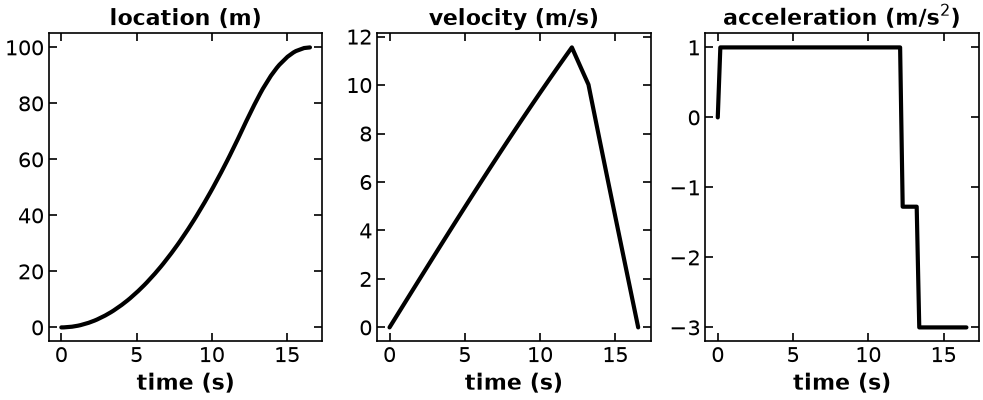

In [6]:
# Define empty lists
x = []  # position, units of length
v = []  # velocity, units of length per time
u = []  # acceleration, units of length per time squared
time = []  # time

# Loop over time and append the solution values for each variable to their respective lists
for i in m.tau:
    time.append(pyo.value(m.time[i]))
    x.append(pyo.value(m.x[i]))
    v.append(pyo.value(m.v[i]))
    u.append(pyo.value(m.u[i]))

# Make a figure
plt.figure(figsize=(12, 4))

# Format subplot 1 (position)
plt.subplot(131)
plt.plot(time, x, linewidth=3, label="x")
plt.title("location (m)", fontsize=16, fontweight="bold")
plt.xlabel("time (s)", fontsize=16, fontweight="bold")
plt.tick_params(direction="in", labelsize=15)

# Format subplot 2 (velocity)
plt.subplot(132)
plt.plot(time, v, linewidth=3, label="v")
plt.xlabel("time (s)", fontsize=16, fontweight="bold")
plt.title("velocity (m/s)", fontsize=16, fontweight="bold")
plt.tick_params(direction="in", labelsize=15)

# Format subplot 3 (acceleration)
plt.subplot(133)
plt.plot(time, u, linewidth=3, label="u")
plt.xlabel("time (s)", fontsize=16, fontweight="bold")
plt.title("acceleration (m/s$^2$)", fontsize=16, fontweight="bold")
plt.tick_params(direction="in", labelsize=15)

plt.show()

**Discussion Questions**

1. How does the time/number of evaluations that IPOPT needs to solve the problem change for a discretized versus non-discretized model?
2. Check to make sure that these results make sense. Based on the known derivative relationships between position, velocity, and acceleration, do the 3 plots make sense? Hint: Match up the trends in each graph.